<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/Heat-Sink-Prediction/blob/main/%E2%80%8BHeat_Sink_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 5 rows of the dataset ---
     Length  Thickness    Height     Pitch  Velocity    Delta_T  \
0  0.087454   0.002038  0.040181  0.010993  6.834313  46.286344   
1  0.145071   0.001958  0.043900  0.010137  2.551477  54.986808   
2  0.123199   0.001051  0.027514  0.007882  8.851551  33.752667   
3  0.109866   0.001682  0.038746  0.005065  6.518046  33.893489   
4  0.065602   0.001760  0.037152  0.009962  2.414835  46.704551   

   Heat_Transfer_Q  Thermal_Resistance  
0      1498.781906            0.030883  
1      2180.850236            0.025213  
2      1768.365925            0.019087  
3      2962.498415            0.011441  
4       676.938957            0.068994   

Model R2 Score (Accuracy): 0.9228



/tmp/ipykernel_620/1623082395.py:71: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(index=pd.cut(df['Height'], bins=10),


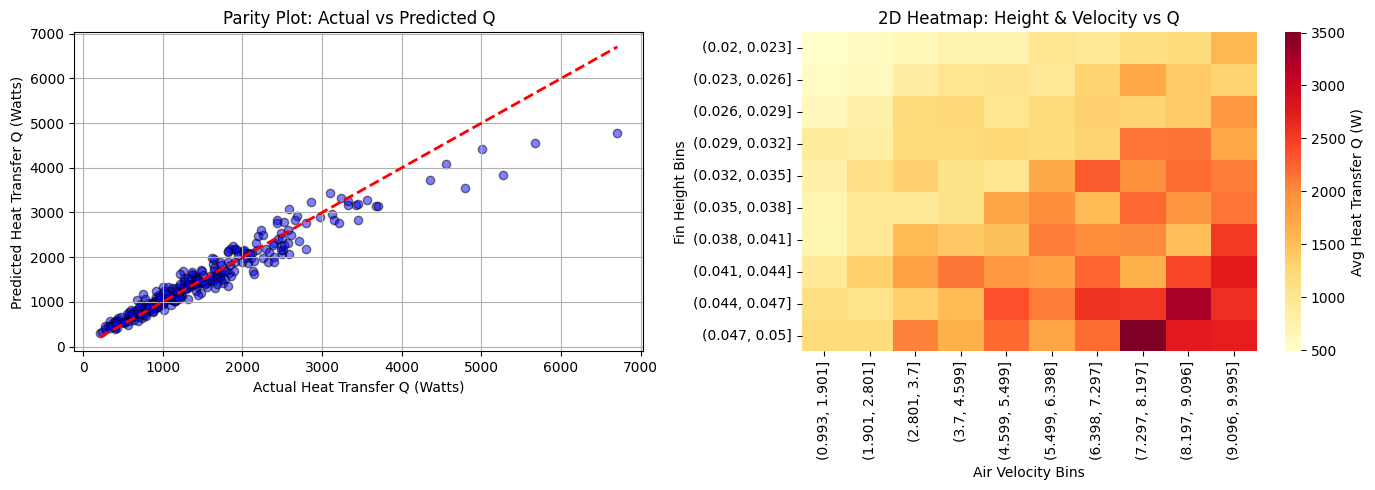

In [ ]:

# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set random seed for reproducibility
np.random.seed(42)

# 2. Generate synthetic dataset based on heat transfer principles
n_samples = 1500

# Input parameter ranges
length = np.random.uniform(0.05, 0.15, n_samples)      # Length (m)
thickness = np.random.uniform(0.001, 0.003, n_samples) # Thickness (m)
height = np.random.uniform(0.02, 0.05, n_samples)      # Height (m)
pitch = np.random.uniform(0.005, 0.015, n_samples)     # Pitch/Spacing (m)
velocity = np.random.uniform(1.0, 10.0, n_samples)     # Air velocity (m/s)
dT = np.random.uniform(30.0, 60.0, n_samples)          # Temperature difference (°C)

# Calculate Heat Transfer (Q) and Thermal Resistance (R_th) using empirical relations
h = 10.4 * (velocity ** 0.5) / (thickness ** 0.1)
surface_area = 2 * height * length * (1.0 / pitch) + (length * pitch)
Q = h * surface_area * dT * np.random.normal(1.0, 0.02, n_samples) # Adding minor noise
R_th = dT / Q

# Create Pandas DataFrame
df = pd.DataFrame({
    'Length': length,
    'Thickness': thickness,
    'Height': height,
    'Pitch': pitch,
    'Velocity': velocity,
    'Delta_T': dT,
    'Heat_Transfer_Q': Q,
    'Thermal_Resistance': R_th
})

print("--- First 5 rows of the dataset ---")
print(df.head(), "\n")

# 3. Machine Learning Model Training (Random Forest Regressor)
X = df[['Length', 'Thickness', 'Height', 'Pitch', 'Velocity', 'Delta_T']]
y_q = df['Heat_Transfer_Q']

X_train, X_test, y_train, y_test = train_test_split(X, y_q, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Model R2 Score (Accuracy): {r2_score(y_test, y_pred):.4f}\n")

# 4. Visualizations
plt.figure(figsize=(14, 5))

# Plot 1: Parity Plot (Actual vs Predicted Heat Transfer Q)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Heat Transfer Q (Watts)')
plt.ylabel('Predicted Heat Transfer Q (Watts)')
plt.title('Parity Plot: Actual vs Predicted Q')
plt.grid(True)

# Plot 2: 2D Heatmap (Fin Height vs Air Velocity vs Heat Transfer Q)
plt.subplot(1, 2, 2)
pivot_table = df.pivot_table(index=pd.cut(df['Height'], bins=10),
                             columns=pd.cut(df['Velocity'], bins=10),
                             values='Heat_Transfer_Q', aggfunc='mean')
sns.heatmap(pivot_table, cmap='YlOrRd', cbar_kws={'label': 'Avg Heat Transfer Q (W)'})
plt.xlabel('Air Velocity Bins')
plt.ylabel('Fin Height Bins')
plt.title('2D Heatmap: Height & Velocity vs Q')

plt.tight_layout()
plt.show()

✅ Step 1: Dataset Created Successfully! Shape: (2000, 8)

📊 Step 2: Model Training & Comparison
 - Linear Regression Accuracy (R2): 0.8610
 - Random Forest Accuracy (R2): 0.9343
 - Gradient Boosting Accuracy (R2): 0.9480


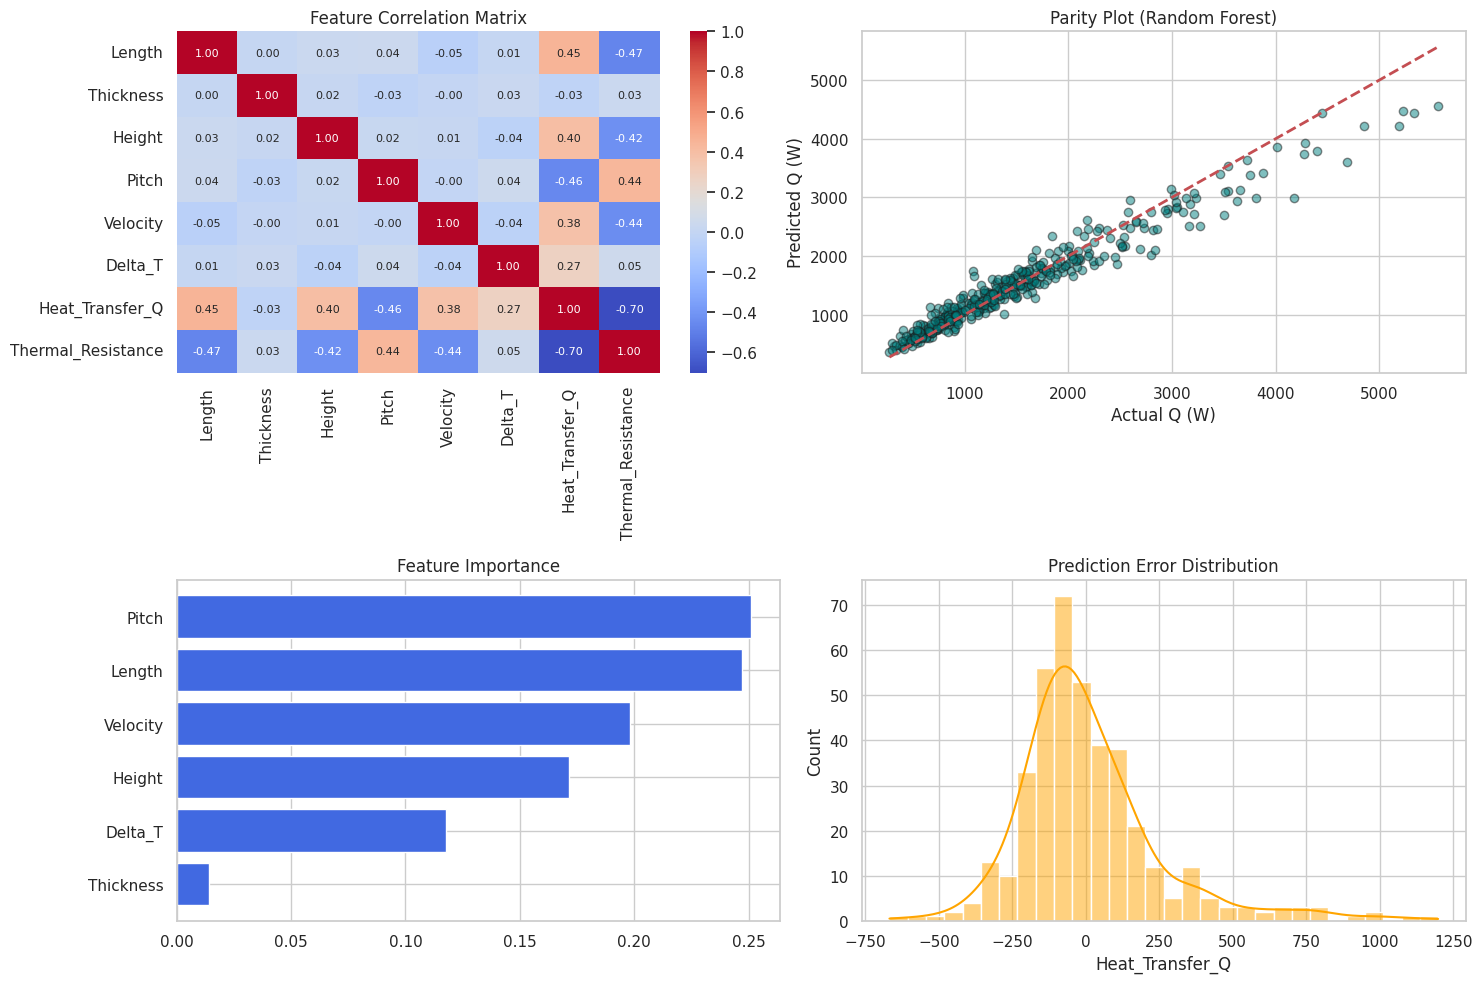


      HEAT SINK PREDICTION REPORT         
 Inputs -> Length: 0.1m | Thickness: 0.002m
           Height: 0.035m | Pitch: 0.01m
           Velocity: 5.0m/s | Delta T: 45.0°C
------------------------------------------
 Predicted Heat Transfer (Q): 1458.43 Watts
 Predicted Thermal Res (R_th): 0.03086 °C/W


In [6]:

# ==========================================
# ADVANCED HEAT SINK PERFORMANCE PREDICTION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Dataset Generation
np.random.seed(42)
n_samples = 2000

length = np.random.uniform(0.05, 0.15, n_samples)
thickness = np.random.uniform(0.001, 0.003, n_samples)
height = np.random.uniform(0.02, 0.05, n_samples)
pitch = np.random.uniform(0.005, 0.015, n_samples)
velocity = np.random.uniform(1.0, 10.0, n_samples)
dT = np.random.uniform(30.0, 60.0, n_samples)

h = 10.4 * (velocity ** 0.5) / (thickness ** 0.1)
surface_area = 2 * height * length * (1.0 / pitch) + (length * pitch)
Q = h * surface_area * dT * np.random.normal(1.0, 0.015, n_samples)
R_th = dT / Q

df = pd.DataFrame({
    'Length': length, 'Thickness': thickness, 'Height': height,
    'Pitch': pitch, 'Velocity': velocity, 'Delta_T': dT,
    'Heat_Transfer_Q': Q, 'Thermal_Resistance': R_th
})

print("✅ Step 1: Dataset Created Successfully! Shape:", df.shape)

# 2. Train-Test Split & Multi-Model Comparison
X = df[['Length', 'Thickness', 'Height', 'Pitch', 'Velocity', 'Delta_T']]
y = df['Heat_Transfer_Q']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print("\n📊 Step 2: Model Training & Comparison")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f" - {name} Accuracy (R2): {r2_score(y_test, y_pred):.4f}")

# Select the best model (Random Forest)
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

# 3. Visualizations (All together)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# Plot A: Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Feature Correlation Matrix')

# Plot B: Parity Plot
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_best, color='teal', alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Q (W)')
plt.ylabel('Predicted Q (W)')
plt.title('Parity Plot (Random Forest)')

# Plot C: Feature Importance
plt.subplot(2, 2, 3)
importances = best_model.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='royalblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Feature Importance')

# Plot D: Residuals
plt.subplot(2, 2, 4)
sns.histplot(y_test - y_pred_best, kde=True, color='orange', bins=30)
plt.title('Prediction Error Distribution')

plt.tight_layout()
plt.show()

# 4. Custom Inference Report
def predict_heat_sink(l, t, h_val, p, v, dt):
    input_data = pd.DataFrame([[l, t, h_val, p, v, dt]], columns=X.columns)
    pred_q = best_model.predict(input_data)[0]
    pred_rth = dt / pred_q

    print("\n==========================================")
    print("      HEAT SINK PREDICTION REPORT         ")
    print("==========================================")
    print(f" Inputs -> Length: {l}m | Thickness: {t}m")
    print(f"           Height: {h_val}m | Pitch: {p}m")
    print(f"           Velocity: {v}m/s | Delta T: {dt}°C")
    print("------------------------------------------")
    print(f" Predicted Heat Transfer (Q): {pred_q:.2f} Watts")
    print(f" Predicted Thermal Res (R_th): {pred_rth:.5f} °C/W")
    print("==========================================")

predict_heat_sink(l=0.10, t=0.002, h_val=0.035, p=0.01, v=5.0, dt=45.0)